# Backend Accuracy Comparison: OpenVINO vs PyTorch

This notebook demonstrates how to compare exported policy accuracy between **OpenVINO** and **PyTorch** backends using the scripts in [`library/scripts/backend_accuracy_comparison/`](../../scripts/backend_accuracy_comparison/).

## Two Complementary Approaches

| Approach | What It Measures | When to Use |
|----------|------------------|-------------|
| **Numerical Comparison** | Single-step prediction differences | Quick export validation |
| **Closed-Loop Benchmark** | Multi-step rollout success rate | Production deployment confidence |

## Why This Matters

When exporting models to OpenVINO:
- Graph optimizations (fusion, quantization) might introduce errors
- Small numerical differences can **accumulate** over 500+ timesteps
- We need to verify **both** numerical equivalence AND behavioral equivalence

This notebook shows:
1. How errors accumulate in closed-loop (with simulator)
2. How to run both benchmark scripts
3. How to interpret results
4. When backends are truly equivalent

## Setup

Install dependencies if you haven't already:

```bash
cd library/scripts/backend_accuracy_comparison
make setup
make check
```

In [ ]:
import sys
import os
from pathlib import Path
import json
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add scripts to path
scripts_dir = Path("../../scripts/backend_accuracy_comparison").resolve()
sys.path.insert(0, str(scripts_dir))

print(f"Scripts directory: {scripts_dir}")
print(f"Exists: {scripts_dir.exists()}")

# HuggingFace authentication — required for gated models:
#   - lerobot/pi05_libero_finetuned_v044  (Pi0.5 finetuned weights)
#   - google/paligemma-3b-pt-224          (VLM tokenizer used by Pi0.5)
#
# Resolution order (canonical HF behavior):
#   1. HF_TOKEN / HUGGING_FACE_HUB_TOKEN environment variable
#   2. ~/.cache/huggingface/token (persisted by `huggingface-cli login`)
#
# We propagate whichever we find into os.environ so subprocesses (cells 9 / 12)
# inherit it via env=os.environ.copy().
from huggingface_hub import HfFolder

token_from_env = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
token_from_disk = HfFolder.get_token()  # reads ~/.cache/huggingface/token

token = token_from_env or token_from_disk
if token:
    os.environ["HF_TOKEN"] = token
    src = "environment" if token_from_env else "~/.cache/huggingface/token"
    print(f"✓ HF token loaded (source: {src})")
else:
    print(
        "✗ No HuggingFace token found.\n"
        "  Run this once in a terminal, then restart the kernel:\n"
        "      huggingface-cli login\n"
        "  Also accept the license for each gated model in your browser:\n"
        "      https://huggingface.co/lerobot/pi05_libero_finetuned_v044\n"
        "      https://huggingface.co/google/paligemma-3b-pt-224"
    )

Scripts directory: /home/pwolnows/forks/physical-ai-studio/library/scripts/backend_accuracy_comparison
Exists: True
HF_TOKEN available: True


---
## Part 1: Understanding Error Accumulation

Let's visualize why closed-loop testing matters.

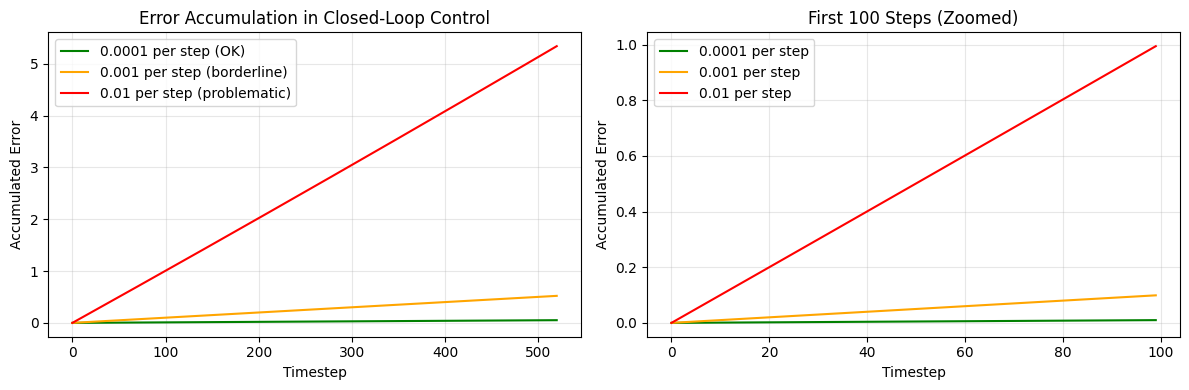


📊 Key Insight:
Even small per-step errors (0.001) can accumulate significantly over 520 steps!
This is why we need closed-loop testing, not just single-step comparison.


In [10]:
# Simulate error accumulation over time
def simulate_error_accumulation(small_error_per_step, num_steps):
    """Simulate how small errors compound in closed-loop control."""
    errors = [0]

    for step in range(num_steps):
        # Each error affects next observation
        # Simplified model: error grows based on previous errors
        accumulated = errors[-1] + small_error_per_step * (1 + errors[-1] * 0.01)
        errors.append(accumulated)

    return errors

# Compare different error magnitudes
steps = 520  # Max steps for libero_10
small_errors = simulate_error_accumulation(0.0001, steps)
medium_errors = simulate_error_accumulation(0.001, steps)
large_errors = simulate_error_accumulation(0.01, steps)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(small_errors, label='0.0001 per step (OK)', color='green')
plt.plot(medium_errors, label='0.001 per step (borderline)', color='orange')
plt.plot(large_errors, label='0.01 per step (problematic)', color='red')
plt.xlabel('Timestep')
plt.ylabel('Accumulated Error')
plt.title('Error Accumulation in Closed-Loop Control')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(small_errors[:100], label='0.0001 per step', color='green')
plt.plot(medium_errors[:100], label='0.001 per step', color='orange')
plt.plot(large_errors[:100], label='0.01 per step', color='red')
plt.xlabel('Timestep')
plt.ylabel('Accumulated Error')
plt.title('First 100 Steps (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Key Insight:")
print("Even small per-step errors (0.001) can accumulate significantly over 520 steps!")
print("This is why we need closed-loop testing, not just single-step comparison.")

---
## Part 2: Prepare a Test Model

We'll use a pretrained Pi0.5 model from HuggingFace Hub.

In [12]:
# Download pretrained Pi0.5 model and save as Lightning checkpoint
#
# We use the NATIVE physicalai.policies.pi05.Pi05 (not the lerobot wrapper)
# because only this class inherits from ExportablePolicyMixin and therefore
# provides .export() / get_supported_export_backends() that the benchmark
# scripts call.
import lightning as L
from dataclasses import fields
from physicalai.policies.pi05 import Pi05
from physicalai.policies.pi05.config import Pi05Config

print("Downloading Pi0.5 model from HuggingFace...")
# Pi05.__init__ with pretrained_name_or_path:
#   1. _from_hf() downloads config.json + model.safetensors and BUILDS Pi05Config
#      from the HF file (which may override defaults like normalization_mode).
#   2. _initialize_model() builds the model and loads the weights eagerly.
policy = Pi05(pretrained_name_or_path='lerobot/pi05_libero_finetuned_v044')
print(f"✓ Loaded {type(policy).__name__} with weights")
print(f"  Actual normalization_mode from HF: {policy.config.normalization_mode}")

# IMPORTANT: `save_hyperparameters` captured the __init__ default kwargs (e.g.
# normalization_mode='QUANTILES'), but `_from_hf` rebuilt `policy.config` with
# values from the HF config.json (e.g. 'MEAN_STD'). On reload, Lightning
# replays __init__ from hparams — so we must overwrite the hparams with the
# real Pi05Config field values, otherwise the preprocessor buffers won't match
# the saved state_dict.
init_arg_names = set(policy.hparams.keys())
for field in fields(Pi05Config):
    if field.name in init_arg_names:
        policy.hparams[field.name] = getattr(policy.config, field.name)

# Save as a Lightning .ckpt that `Pi05.load_from_checkpoint()` can re-load.
checkpoint_path = Path("test_pi05.ckpt").resolve()
checkpoint = {
    "state_dict": policy.state_dict(),
    "hyper_parameters": dict(policy.hparams),
    "hparams_name": "kwargs",
    "pytorch-lightning_version": L.__version__,
    "epoch": 0,
    "global_step": 0,
}
torch.save(checkpoint, checkpoint_path)

print(f"✓ Saved Lightning checkpoint to {checkpoint_path}")
print(f"  Use --policy-class physicalai.policies.pi05.Pi05 in benchmark scripts")

✓ Loaded Pi05 with weights
  Actual normalization_mode from HF: MEAN_STD
✓ Saved Lightning checkpoint to /home/pwolnows/forks/physical-ai-studio/library/notebooks/benchmark/test_pi05.ckpt
  Use --policy-class physicalai.policies.pi05.Pi05 in benchmark scripts


---
## Part 3: Numerical Comparison (Quick Check)

First, let's verify the export is numerically lossless.

This tests **single-step predictions** on dataset samples - no simulator involved.

In [ ]:
# Run numerical comparison script
print("Running numerical comparison...")
print("This compares single-step predictions on dataset samples.\n")

cmd = [
    "python", str(scripts_dir / "numerical_comparison.py"),
    "--checkpoint", str(checkpoint_path),
    "--policy-class", "physicalai.policies.pi05.Pi05",  # Native Pi05 has ExportablePolicyMixin
    "--dataset", "lerobot/libero_10_image",  # matches libero_10 task suite used in closed-loop below
    "--num-samples", "50",
    "--output", "results/demo_numerical.json"
]

# Pass current env (including HF_TOKEN) to the child process explicitly.
result = subprocess.run(
    cmd, capture_output=True, text=True, cwd=scripts_dir, env=os.environ.copy(),
)

print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)


Running numerical comparison...
This compares single-step predictions on dataset samples.

[torch.onnx] Obtain model graph for `Pi05Model([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Pi05Model([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

Errors: 2026-05-18 12:56:10,806 - INFO - Starting Numerical Backend Comparison
2026-05-18 12:56:10,806 - INFO - Checkpoint: /home/pwolnows/forks/physical-ai-studio/library/notebooks/benchmark/test_pi05.ckpt
2026-05-18 12:56:10,806 - INFO - Policy: physicalai.policies.pi05.Pi05
2026-05-18 12:56:10,806 - INFO - Dataset: lerobot/libero_spatial
2026-05-18 12:56:10,806 - INFO - Num samples: 5
[robosuite WARNING] No private macro file found! (__init__.py:7)
2026-05-18 12:56:14,016 - WARNING - No private macro file found!
[robosuite WARN

In [ ]:
# Load and visualize numerical results
with open(scripts_dir / "results/demo_numerical.json") as f:
    numerical_results = json.load(f)

comp = numerical_results["comparison"]
analysis = numerical_results["analysis"]

print("\n" + "="*70)
print("NUMERICAL COMPARISON RESULTS")
print("="*70)
print(f"\nSamples analyzed: {comp['num_samples']}")
print(f"Max absolute difference: {analysis['max_diff']:.8f}")
print(f"Mean absolute difference: {analysis['mean_diff']:.8f}")
print(f"P99 difference: {comp['p99_max_diff']:.8f}")
print(f"\n{analysis['conclusion']}")
print("="*70)

# Visualize per-sample differences
if comp['per_sample_max_diffs']:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(comp['per_sample_max_diffs'], bins=30, edgecolor='black')
    plt.xlabel('Max Absolute Difference')
    plt.ylabel('Number of Samples')
    plt.title('Distribution of Per-Sample Max Differences')
    plt.axvline(analysis['threshold_practical'], color='red', linestyle='--',
                label=f'bfloat16 threshold ({analysis["threshold_practical"]:.0e})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(comp['per_sample_max_diffs'], marker='o', linestyle='', alpha=0.6)
    plt.xlabel('Sample Index')
    plt.ylabel('Max Absolute Difference')
    plt.title('Per-Sample Differences')
    plt.axhline(analysis['threshold_practical'], color='red', linestyle='--',
                label=f'bfloat16 threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Interpretation: Numerical Results

✅ **If max_diff < 0.001:** Export is numerically lossless (bfloat16 precision)
⚠️ **If max_diff between 0.001-0.01:** Small differences (may be acceptable)
❌ **If max_diff > 0.01:** Significant numerical error - investigate export

**BUT:** Numerical equivalence doesn't guarantee behavioral equivalence!

Even tiny errors can accumulate over 520 timesteps → we need closed-loop testing.

---
## Part 4: Closed-Loop Benchmark (Real Accuracy)

Now let's test with the **full simulator** where errors can accumulate.

This runs complete episodes in LiberoGym + MuJoCo where:
- Each action affects the next observation
- Errors compound over 520 timesteps
- Success depends on completing the actual task

In [ ]:
# Run closed-loop benchmark
print("Running closed-loop benchmark...")
print("This runs full episodes in MuJoCo simulator.\n")
print("⏱️  This will take ~5-10 minutes...\n")

cmd = [
    "python", str(scripts_dir / "closed_loop_benchmark.py"),
    "--checkpoint", str(checkpoint_path),
    "--policy-class", "physicalai.policies.pi05.Pi05",  # Native Pi05 has ExportablePolicyMixin
    "--task-suite", "libero_10",
    "--task-ids", "0", "1",  # Just 2 tasks for demo
    "--num-episodes", "5",    # 5 episodes per task
    "--seed", "42",
    "--output", "results/demo_closed_loop.json"
]

# Pass current env (including HF_TOKEN) to the child process explicitly.
result = subprocess.run(
    cmd, capture_output=True, text=True, cwd=scripts_dir, env=os.environ.copy(),
)

print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

In [ ]:
# Load and visualize closed-loop results
with open(scripts_dir / "results/demo_closed_loop.json") as f:
    closed_loop_results = json.load(f)

pytorch_res = closed_loop_results["pytorch"]
openvino_res = closed_loop_results["openvino"]
comparison = closed_loop_results["comparison"]

print("\n" + "="*70)
print("CLOSED-LOOP BENCHMARK RESULTS")
print("="*70)

print(f"\n{'Backend':<15} {'Success Rate':>15} {'Avg Reward':>12} {'Avg FPS':>10}")
print("-"*70)
print(f"{'PyTorch':<15} {pytorch_res['overall_success_rate']:>14.1f}% "
      f"{np.mean([t['avg_reward'] for t in pytorch_res['task_results']]):>12.3f} "
      f"{np.mean([t['avg_fps'] for t in pytorch_res['task_results']]):>10.2f}")
print(f"{'OpenVINO':<15} {openvino_res['overall_success_rate']:>14.1f}% "
      f"{np.mean([t['avg_reward'] for t in openvino_res['task_results']]):>12.3f} "
      f"{np.mean([t['avg_fps'] for t in openvino_res['task_results']]):>10.2f}")
print("-"*70)
print(f"{'Delta':<15} {comparison['overall_success_rate_delta']:>14.1f}%")
print("\n" + comparison['conclusion'])
print("="*70)

# Visualize per-task comparison
task_names = [t['task_id'] for t in pytorch_res['task_results']]
pt_success = [t['success_rate'] for t in pytorch_res['task_results']]
ov_success = [t['success_rate'] for t in openvino_res['task_results']]

x = np.arange(len(task_names))
width = 0.35

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(x - width/2, pt_success, width, label='PyTorch', alpha=0.8)
plt.bar(x + width/2, ov_success, width, label='OpenVINO', alpha=0.8)
plt.xlabel('Task')
plt.ylabel('Success Rate (%)')
plt.title('Per-Task Success Rate Comparison')
plt.xticks(x, [t.replace('libero_10_', 'Task ') for t in task_names])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
deltas = [abs(pt - ov) for pt, ov in zip(pt_success, ov_success)]
plt.bar(task_names, deltas, color='orange', alpha=0.7)
plt.axhline(5.0, color='red', linestyle='--', label='5% threshold')
plt.xlabel('Task')
plt.ylabel('Success Rate Delta (%)')
plt.title('Absolute Difference Between Backends')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Interpretation: Closed-Loop Results

✅ **If delta < 5%:** Backends are equivalent (within measurement noise)
⚠️ **If delta 5-10%:** Borderline - increase num_episodes for confidence
❌ **If delta > 10%:** Investigate! Check numerical comparison first

**Key insight:** Success rate shows **real-world accuracy** after error accumulation.

---
## Part 5: Combined Analysis

Let's compare both approaches side-by-side.

In [ ]:
# Create comprehensive comparison table
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Numerical: Distribution of differences
ax = axes[0, 0]
diffs = comp['per_sample_max_diffs']
ax.hist(diffs, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(analysis['threshold_practical'], color='red', linestyle='--',
           label=f'Threshold: {analysis["threshold_practical"]:.0e}')
ax.set_xlabel('Max Absolute Difference')
ax.set_ylabel('Frequency')
ax.set_title('Numerical: Distribution of Prediction Differences')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Numerical: Summary stats
ax = axes[0, 1]
metrics = ['Max', 'P99', 'P95', 'Mean']
values = [analysis['max_diff'], comp['p99_max_diff'],
          comp['p95_max_diff'], analysis['mean_diff']]
colors = ['red' if v > analysis['threshold_practical'] else 'green' for v in values]
bars = ax.barh(metrics, values, color=colors, alpha=0.7)
ax.axvline(analysis['threshold_practical'], color='black', linestyle='--',
           label=f'bfloat16 threshold')
ax.set_xlabel('Absolute Difference')
ax.set_title('Numerical: Summary Statistics')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 3. Closed-loop: Per-task comparison
ax = axes[1, 0]
x = np.arange(len(task_names))
width = 0.35
ax.bar(x - width/2, pt_success, width, label='PyTorch', alpha=0.8, color='blue')
ax.bar(x + width/2, ov_success, width, label='OpenVINO', alpha=0.8, color='orange')
ax.set_xlabel('Task')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Closed-Loop: Success Rate Comparison')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('libero_10_', 'T') for t in task_names])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Closed-loop: Overall comparison
ax = axes[1, 1]
backends = ['PyTorch', 'OpenVINO']
success_rates = [pytorch_res['overall_success_rate'], openvino_res['overall_success_rate']]
colors = ['blue', 'orange']
bars = ax.bar(backends, success_rates, color=colors, alpha=0.7)
for i, (backend, rate) in enumerate(zip(backends, success_rates)):
    ax.text(i, rate + 1, f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.axhline(comparison['threshold'], color='red', linestyle='--', alpha=0.5,
           label=f'±{comparison["threshold"]:.0f}% tolerance')
ax.set_ylabel('Overall Success Rate (%)')
ax.set_title(f'Closed-Loop: Overall Results\n(Delta: {comparison["overall_success_rate_delta"]:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print combined verdict
print("\n" + "="*80)
print("COMBINED VERDICT")
print("="*80)

numerical_ok = analysis['is_equivalent']
closed_loop_ok = comparison['is_equivalent']

print(f"\n✓ Numerical Comparison: {'PASS' if numerical_ok else 'FAIL'}")
print(f"  Max diff: {analysis['max_diff']:.8f} (threshold: {analysis['threshold_practical']:.8f})")

print(f"\n✓ Closed-Loop Benchmark: {'PASS' if closed_loop_ok else 'FAIL'}")
print(f"  Success rate delta: {comparison['overall_success_rate_delta']:.1f}% (threshold: {comparison['threshold']:.0f}%)")

if numerical_ok and closed_loop_ok:
    print("\n" + "🎉 " * 20)
    print("✅ CONCLUSION: OpenVINO export is PRODUCTION READY")
    print("   Both numerical and behavioral accuracy are preserved.")
    print("🎉 " * 20)
elif numerical_ok and not closed_loop_ok:
    print("\n⚠️  WARNING: Numerical OK but closed-loop differs")
    print("   Possible causes:")
    print("   1. Measurement noise - try more episodes (--num-episodes 50)")
    print("   2. Simulator randomness - verify same seed used")
    print("   3. Model uses stochastic components (e.g., dropout at inference)")
elif not numerical_ok:
    print("\n❌ PROBLEM: Numerical differences detected")
    print("   Export may have issues. Investigate:")
    print("   1. Check export implementation for this policy type")
    print("   2. Verify input preprocessing matches")
    print("   3. Check if quantization was accidentally enabled")

print("="*80)

---
## Part 6: Decision Matrix

Use this to decide which benchmark to run when:

In [ ]:
# Create decision matrix visualization
fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Speed', 'Accuracy\nValidation', 'Production\nReadiness', 'Debug\nCapability', 'Error\nAccumulation']
numerical_scores = [5, 3, 2, 5, 1]  # Out of 5
closed_loop_scores = [2, 5, 5, 3, 5]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, numerical_scores, width, label='Numerical Comparison',
               alpha=0.8, color='lightblue')
bars2 = ax.bar(x + width/2, closed_loop_scores, width, label='Closed-Loop Benchmark',
               alpha=0.8, color='lightcoral')

ax.set_ylabel('Score (1-5)')
ax.set_title('Benchmark Comparison: When to Use Each Approach')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 6)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📋 Decision Guide:")
print("\n1. Quick export validation → numerical_comparison.py")
print("   ⏱️  Fast (2 minutes)")
print("   ✓ Verifies export is lossless")
print("\n2. Production deployment confidence → closed_loop_benchmark.py")
print("   ⏱️  Slow (30 minutes)")
print("   ✓ Verifies real-world accuracy")
print("\n3. Best practice → Run BOTH")
print("   - Numerical first (2 min) - quick sanity check")
print("   - Closed-loop second (30 min) - comprehensive validation")

---
## Summary & Next Steps

### What We Learned

1. **Error Accumulation Matters**
   - Small per-step errors (0.001) compound significantly over 520 timesteps
   - Single-step validation is not enough for production confidence

2. **Two Complementary Tests**
   - **Numerical:** Fast sanity check (export is lossless)
   - **Closed-Loop:** Comprehensive validation (robot can complete tasks)

3. **Interpretation**
   - Both tests must pass for production readiness
   - Numerical < 0.001 → Export OK
   - Success rate delta < 5% → Backends equivalent

### Next Steps

For your own models:

```bash
cd library/scripts/backend_accuracy_comparison

# 1. Train your model
physicalai train --policy physicalai.policies.ACT ...

# 2. Run numerical check (quick)
python numerical_comparison.py \
    --checkpoint path/to/your/checkpoint.ckpt \
    --policy-class physicalai.policies.ACT \
    --dataset lerobot/your_dataset \
    --num-samples 100

# 3. Run closed-loop benchmark (comprehensive)
python closed_loop_benchmark.py \
    --checkpoint path/to/your/checkpoint.ckpt \
    --policy-class physicalai.policies.ACT \
    --task-suite libero_10 \
    --num-episodes 50

# 4. Compare multiple models
python batch_comparison.py --models \
    "model1:path1.ckpt:policy.Class1" \
    "model2:path2.ckpt:policy.Class2"
```

### Resources

- **Scripts README:** [`../../scripts/backend_accuracy_comparison/README.md`](../../scripts/backend_accuracy_comparison/README.md)
- **LIBERO Guide:** [`libero.ipynb`](libero.ipynb)
- **Export Guide:** [`../../docs/how-to/export/export_inference.md`](../../docs/how-to/export/export_inference.md)

---
## Cleanup

```python
# Remove test files
import os
os.remove("test_pi05.ckpt")
print("✓ Cleanup complete")
```